In [1]:
print("Spam Detection Project")

Spam Detection Project


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("spam.csv")

df.head()

,label,message
0,ham,Hey how are you doing today
1,ham,Can you call me when you are free
2,spam,Congratulations you won a free prize
3,ham,Please bring some milk on your way home
4,spam,You have won 10000 dollars click now


In [4]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (30, 2)

Missing values:
label      0
message    0
dtype: int64


In [5]:
print(df["label"].value_counts())

label
ham     16
spam    14
Name: count, dtype: int64


In [6]:
X = df["message"]
y = df["label"]

print("Text data and labels selected successfully!")

Text data and labels selected successfully!


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 24
Testing messages: 6


In [8]:
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", MultinomialNB())
])

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [9]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print(y_pred)

Predictions completed!
['spam' 'ham' 'ham' 'spam' 'spam' 'ham']


In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="spam")
recall = recall_score(y_test, y_pred, pos_label="spam")
f1 = f1_score(y_test, y_pred, pos_label="spam")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.6666666666666666
Precision: 0.6666666666666666
Recall   : 0.6666666666666666
F1 Score : 0.6666666666666666


In [11]:
cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2 1]
 [1 2]]


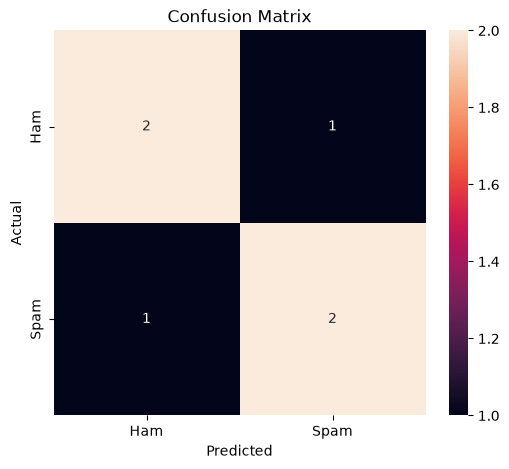

In [12]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [13]:
message = ["Congratulations! You have won a free prize"]

prediction = model.predict(message)

print("Message:", message[0])
print("Prediction:", prediction[0])

Message: Congratulations! You have won a free prize
Prediction: spam


In [14]:
import joblib

joblib.dump(model, "spam_detection_pipeline.pkl")

print("Pipeline saved successfully!")

Pipeline saved successfully!
